In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# Setup: Gaussian storm on 0.25-degree grid
rng = np.random.default_rng(0)
lats_f = np.arange(25, 50, 0.25)
lons_f = np.arange(-120, -70, 0.25)
LON, LAT = np.meshgrid(lons_f, lats_f)
storm = 30 * np.exp(-((LAT - 37)**2 / 3 + (LON + 100)**2 / 3))
precip = storm + 0.5 + rng.exponential(0.3, storm.shape)
ds_fine = xr.Dataset(
    {'precip': (['lat', 'lon'], precip, {'units': 'mm/day'})},
    coords={'lat': lats_f, 'lon': lons_f}
)

# Regrid to 1-degree using bilinear
lats_c = np.arange(25.5, 50, 1.0)
lons_c = np.arange(-119.5, -70, 1.0)
ds_bil = ds_fine.interp(lat=lats_c, lon=lons_c)

# Full diagnostics
w_f = np.cos(np.radians(ds_fine.lat)) * 0.25 * 0.25
w_c = np.cos(np.radians(ds_bil.lat))  * 1.0  * 1.0

mass_fine = float((ds_fine['precip'] * w_f).sum())
mass_bil  = float((ds_bil['precip']  * w_c).sum())

print("=== Diagnostic Report: Bilinear Regrid ===")
print(f"Source mean : {float(ds_fine['precip'].mean()):.4f} mm/day")
print(f"Target mean : {float(ds_bil['precip'].mean()):.4f} mm/day")
print(f"Mass before : {mass_fine:.2f}")
print(f"Mass after  : {mass_bil:.2f}")
print(f"Mass error  : {(mass_bil - mass_fine) / mass_fine * 100:.3f}%")
print(f"Source range: [{float(ds_fine['precip'].min()):.2f}, {float(ds_fine['precip'].max()):.2f}]")
print(f"Target range: [{float(ds_bil['precip'].min()):.2f}, {float(ds_bil['precip'].max()):.2f}]")
print(f"NaNs in target: {int(ds_bil['precip'].isnull().sum())}")

=== Diagnostic Report: Bilinear Regrid ===
Source mean : 1.0241 mm/day
Target mean : 1.0118 mm/day
Mass before : 1012.12
Mass after  : 997.29
Mass error  : -1.466%
Source range: [0.50, 31.26]
Target range: [0.50, 26.57]
NaNs in target: 0


1D mass before : 111.9600
1D mass after  : 111.9600
1D mass error  : 0.000000%


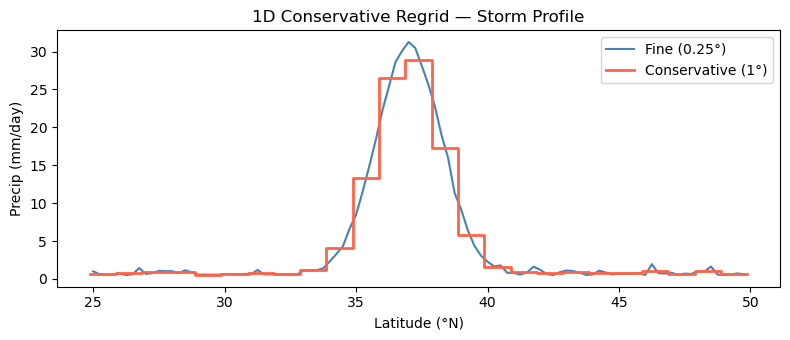

In [2]:
def conservative_regrid_1d(f_src, src_edges, tgt_edges):
    """
    Conservative regridding in 1D.
    f_src:     values on source grid
    src_edges: source cell boundaries (len = len(f_src) + 1)
    tgt_edges: target cell boundaries (len = len(output) + 1)
    Returns: values on target grid, conserving the area-weighted integral
    """
    n_tgt = len(tgt_edges) - 1
    out = np.zeros(n_tgt)

    for i in range(n_tgt):
        t0, t1 = tgt_edges[i], tgt_edges[i + 1]
        tgt_width = t1 - t0
        weighted_sum = 0.0

        for k in range(len(f_src)):
            s0, s1 = src_edges[k], src_edges[k + 1]
            # overlap between source cell [s0, s1] and target cell [t0, t1]
            overlap = max(0.0, min(s1, t1) - max(s0, t0))
            if overlap > 0:
                weighted_sum += f_src[k] * overlap

        out[i] = weighted_sum / tgt_width  # normalize by target cell width

    return out

# Test: 1D latitude slice through storm center
lon_idx = np.argmin(np.abs(lons_f - (-100)))
f_src   = ds_fine['precip'].values[:, lon_idx]  # 100 values, centers at lats_f

# Build edges from cell centers: first/last edge = center +/- half-width
src_dlat  = float(lats_f[1] - lats_f[0])  # 0.25 deg
src_edges = np.append(lats_f - src_dlat / 2, lats_f[-1] + src_dlat / 2)
# [24.875, 25.125, ..., 49.875] — 101 edges for 100 cells

# Target: match outer domain exactly so no mass leaks at boundaries
tgt_edges = np.arange(src_edges[0], src_edges[-1] + 0.001, 1.0)
# [24.875, 25.875, ..., 49.875] — 26 edges, 25 cells
tgt_ctrs  = 0.5 * (tgt_edges[:-1] + tgt_edges[1:])

f_tgt = conservative_regrid_1d(f_src, src_edges, tgt_edges)

# Check conservation: integral (sum × cell width) before vs after
mass_before = np.sum(f_src * np.diff(src_edges))
mass_after  = np.sum(f_tgt * np.diff(tgt_edges))
print(f"1D mass before : {mass_before:.4f}")
print(f"1D mass after  : {mass_after:.4f}")
print(f"1D mass error  : {(mass_after - mass_before) / mass_before * 100:.6f}%")

# Plot comparison
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(lats_f, f_src, color='steelblue', linewidth=1.5, label='Fine (0.25°)')
ax.step(np.append(tgt_edges[:-1], tgt_edges[-1]),
        np.append(f_tgt, f_tgt[-1]),
        where='post', color='tomato', linewidth=2.0, label='Conservative (1°)')
ax.set_xlabel('Latitude (°N)')
ax.set_ylabel('Precip (mm/day)')
ax.set_title('1D Conservative Regrid — Storm Profile')
ax.legend()
plt.tight_layout()
plt.show()